In [85]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import numpy
import seaborn as sns
import matplotlib
import joblib
from dataloader import load_project_data
import os

In [86]:
path = "../project_dashboard/datasets"
if os.path.exists(path):
    df = load_project_data(path)


# Cleaning Dictionary

In [87]:
df.keys()

dict_keys(['covid_deaths_linelist', 'infant_immunisation', 'pekab40_screenings_state', 'blood_donations_state', 'covid_cases', 'blood_donations'])

In [88]:
df["covid_deaths_linelist"].size

560265

In [89]:
# Shape of dataframes
for key in df.keys():
    print(key)
    print(f"Size of Dataframe:{df[key].shape}")

covid_deaths_linelist
Size of Dataframe:(37351, 15)
infant_immunisation
Size of Dataframe:(120, 3)
pekab40_screenings_state
Size of Dataframe:(40416, 3)
blood_donations_state
Size of Dataframe:(479570, 4)
covid_cases
Size of Dataframe:(33218, 7)
blood_donations
Size of Dataframe:(36890, 3)


In [90]:
# Conversion to singular dataframes
# Infant immunisation, pekab40_screening, blood donation and blood doantions were ignored due to lack of features
covid_deaths = df["covid_deaths_linelist"]
covid_cases = df["covid_cases"]

In [91]:
covid_cases.head()

,date,state,cases_new,cases_import,cases_recovered,cases_active,cases_cluster
0,2020-01-25,Malaysia,4,4,0,4,0
1,2020-01-26,Malaysia,0,0,0,4,0
2,2020-01-27,Malaysia,0,0,0,4,0
3,2020-01-28,Malaysia,0,0,0,4,0
4,2020-01-29,Malaysia,3,3,0,7,0


In [92]:
covid_deaths.head()

,date,date_announced,date_positive,date_dose1,date_dose2,date_dose3,brand1,brand2,brand3,state,age,male,bid,malaysian,comorb
0,2020-03-17,2020-03-17,2020-03-12,NaN,NaN,NaN,NaN,NaN,NaN,Johor,34,1,0,1,1
1,2020-03-17,2020-03-17,2020-03-15,NaN,NaN,NaN,NaN,NaN,NaN,Sarawak,60,1,0,1,1
2,2020-03-20,2020-03-20,2020-03-11,NaN,NaN,NaN,NaN,NaN,NaN,Sabah,58,1,0,1,1
3,2020-03-21,2020-03-21,2020-03-13,NaN,NaN,NaN,NaN,NaN,NaN,Melaka,50,1,0,1,1
4,2020-03-22,2020-03-22,2020-03-20,NaN,NaN,NaN,NaN,NaN,NaN,Sarawak,80,0,1,1,1


In [93]:
# One hot encoding of covid_cases
print(f"{covid_cases['state'].unique()}")
print(f"{covid_deaths['state'].unique()}")

['Malaysia' 'Johor' 'Kedah' 'Kelantan' 'Melaka' 'Negeri Sembilan' 'Pahang'
 'Perak' 'Perlis' 'Pulau Pinang' 'Sabah' 'Sarawak' 'Selangor' 'Terengganu'
 'W.P. Kuala Lumpur' 'W.P. Labuan' 'W.P. Putrajaya']
['Johor' 'Sarawak' 'Sabah' 'Melaka' 'W.P. Kuala Lumpur' 'Kelantan'
 'Perlis' 'Pulau Pinang' 'Selangor' 'Kedah' 'Perak' 'Negeri Sembilan'
 'W.P. Putrajaya' 'Pahang' 'Terengganu' 'W.P. Labuan']


In [94]:
# One hot encoding of covid_deaths_linelist
states = [
    "Malaysia"
    "Johor"
    "Kedah"
    "Kelantan"
    "Melakaencoded_covid_deaths[date_cols_covid_deaths] = encoded_covid_deaths[date_cols_covid_deaths].apply(pd.to_datetime)"
    "Negeri Sembilan"
    "Pahang"
    "Perak"
    "Perlis"
    "Pulau Pinang"
    "Sabah"
    "Sarawak"
    "Selangor"
    "Terengganu"
    "W.P. Kuala Lumpur"
    "W.P. Labuan"
    "W.P. Putrajaya"
]
# Get dummies
encoded_covid_deaths = pd.get_dummies(covid_deaths, columns=["state"])
encoded_covid_cases = pd.get_dummies(covid_cases, columns=["state"])
# Convert dates to datetime format
date_cols_covid_deaths = encoded_covid_deaths.filter(like="date").columns
date_cols_covid_cases = encoded_covid_cases.filter(like="date").columns
encoded_covid_deaths[date_cols_covid_deaths] = encoded_covid_deaths[
    date_cols_covid_deaths
].apply(pd.to_datetime)
encoded_covid_cases[date_cols_covid_cases] = encoded_covid_cases[
    date_cols_covid_cases
].apply(pd.to_datetime)
df_covid_cases = encoded_covid_cases
df_covid_deaths = encoded_covid_deaths

# Imputation

In [ ]:
# Dropping dosage dates and brands as they take up a large proportion of the dataframe.
# df_covid_deaths.isnull().sum()
df_covid_deaths = df_covid_deaths.drop(
    columns=[
        "date_dose1",
        "date_dose2",
        "date_dose3",
        "brand1",
        "brand2",
        "brand3",
        "date",
        "date_positive",
    ]
)
df_covid_cases = df_covid_cases.drop(columns=["state_Malaysia"])


In [103]:
print(df_covid_cases.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33218 entries, 0 to 33217
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     33218 non-null  datetime64[ns]
 1   cases_new                33218 non-null  int64         
 2   cases_import             33218 non-null  int64         
 3   cases_recovered          33218 non-null  int64         
 4   cases_active             33218 non-null  int64         
 5   cases_cluster            33218 non-null  int64         
 6   state_Johor              33218 non-null  bool          
 7   state_Kedah              33218 non-null  bool          
 8   state_Kelantan           33218 non-null  bool          
 9   state_Melaka             33218 non-null  bool          
 10  state_Negeri Sembilan    33218 non-null  bool          
 11  state_Pahang             33218 non-null  bool          
 12  state_Perak              33218 n

In [104]:
print(df_covid_deaths.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37351 entries, 0 to 37350
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date_announced           37351 non-null  datetime64[ns]
 1   age                      37351 non-null  int64         
 2   male                     37351 non-null  int64         
 3   bid                      37351 non-null  int64         
 4   malaysian                37351 non-null  int64         
 5   comorb                   37351 non-null  int64         
 6   state_Johor              37351 non-null  bool          
 7   state_Kedah              37351 non-null  bool          
 8   state_Kelantan           37351 non-null  bool          
 9   state_Melaka             37351 non-null  bool          
 10  state_Negeri Sembilan    37351 non-null  bool          
 11  state_Pahang             37351 non-null  bool          
 12  state_Perak              37351 n

In [ ]:
# Do seperate feature selection and train test splits for both covid cases and deaths

In [106]:
# Feature Selection for Covid Deaths and Cases
X_cases = df_covid_cases.drop(columns=["date", "state", "cases_new"])
y_cases = df_covid_cases["cases_new"]

# Temporal Split (Assuming sorted by date)
split = int(len(X_cases) * 0.8)
X_train_c, X_test_c = X_cases[:split], X_cases[split:]
y_train_c, y_test_c = y_cases[:split], y_cases[split:]

In [105]:
from sklearn.preprocessing import StandardScaler

# Separate Features and Target
X_deaths = df_covid_deaths.drop(columns=["date_announced", "state", "bid"])
y_deaths = df_covid_deaths["bid"]

# Scale the 'age' column only
scaler = StandardScaler()
X_deaths["age"] = scaler.fit_transform(X_deaths[["age"]])

# Stratified Split (Random is okay here as it's individual data)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_deaths, y_deaths, test_size=0.2, stratify=y_deaths, random_state=42
)


In [107]:
# Model Training for Covid Cases
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Train
reg_model = XGBRegressor(n_estimators=100, learning_rate=0.05)
reg_model.fit(X_train_c, y_train_c)

# Evaluate
preds_c = reg_model.predict(X_test_c)
print(f"Mean Absolute Error: {mean_absolute_error(y_test_c, preds_c)}")
print(f"R2 Score: {r2_score(y_test_c, preds_c)}")  # Closer to 1.0 is better

Mean Absolute Error: 32.74493408203125
R2 Score: 0.8689433336257935


In [ ]:
# Model Training for Covid Deaths
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train
# Use 'balanced' because BID cases are usually a minority
clf_model = RandomForestClassifier(n_estimators=200, class_weight="balanced")
clf_model.fit(X_train_d, y_train_d)

# Evaluate
preds_d = clf_model.predict(X_test_d)
print(confusion_matrix(y_test_d, preds_d))
print(classification_report(y_test_d, preds_d))

[[4589 1293]
 [ 874  715]]
              precision    recall  f1-score   support

           0       0.84      0.78      0.81      5882
           1       0.36      0.45      0.40      1589

    accuracy                           0.71      7471
   macro avg       0.60      0.62      0.60      7471
weighted avg       0.74      0.71      0.72      7471



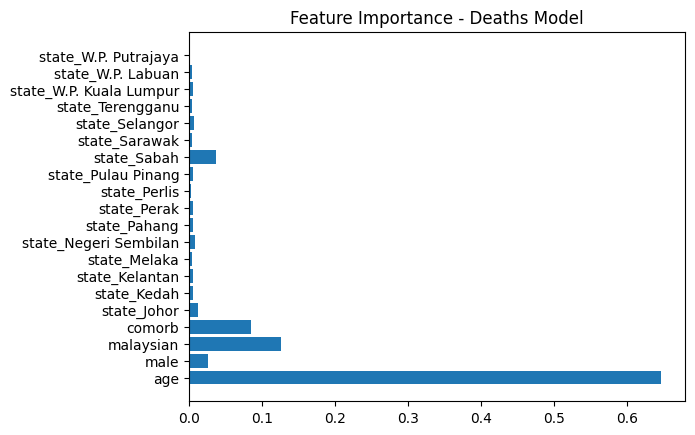

In [109]:
# Evaluation
import matplotlib.pyplot as plt

importances = clf_model.feature_importances_
indices = X_deaths.columns
plt.barh(indices, importances)
plt.title("Feature Importance - Deaths Model")
plt.show()

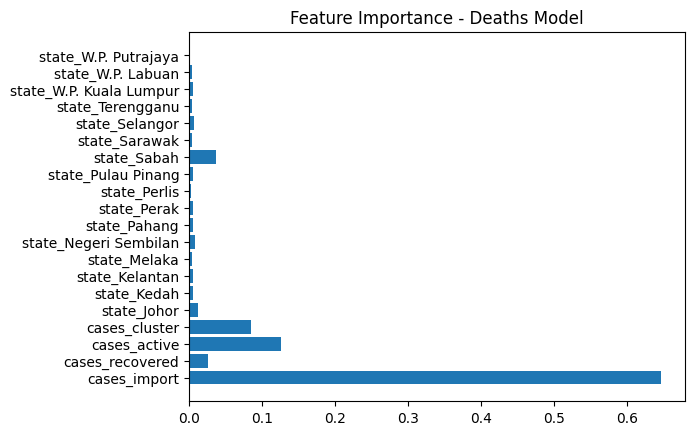

In [110]:
import matplotlib.pyplot as plt

importances = clf_model.feature_importances_
indices = X_cases.columns
plt.barh(indices, importances)
plt.title("Feature Importance - Deaths Model")
plt.show()


In [111]:
import joblib

# Save the Cases Regressor
joblib.dump(reg_model, "cases_model.pkl")

# Save the Deaths Classifier
joblib.dump(clf_model, "deaths_model.pkl")

# IMPORTANT: Save the Scaler if you used one for Age
joblib.dump(scaler, "age_scaler.pkl")


['age_scaler.pkl']

# Tensorflow

In [112]:
import tensorflow as tf
from tensorflow.keras import layers, models

# For Cases (Regression)
X_train_c = X_train_c.astype("float32")
y_train_c = y_train_c.astype("float32")

# For Deaths (Classification)
X_train_d = X_train_d.astype("float32")
y_train_d = y_train_d.astype("float32")


I0000 00:00:1777125137.826899   80422 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777125137.831365   80422 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777125138.307565   80422 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777125139.873867   80422 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [113]:
model_cases = models.Sequential(
    [
        layers.Input(shape=(X_train_c.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),  # No activation for regression
    ]
)

model_cases.compile(optimizer="adam", loss="mse", metrics=["mae"])

# Train
model_cases.fit(X_train_c, y_train_c, epochs=50, batch_size=32, validation_split=0.2)


Epoch 1/50


E0000 00:00:1777125157.950095   80422 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


665/665 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 269513.9375 - mae: 141.9268 - val_loss: 140435.3906 - val_mae: 129.0963
Epoch 2/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 1s 864us/step - loss: 283770.7188 - mae: 141.3493 - val_loss: 95983.6094 - val_mae: 110.9377
Epoch 3/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 1s 901us/step - loss: 201650.0938 - mae: 135.0902 - val_loss: 95784.5078 - val_mae: 110.9284
Epoch 4/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 1s 868us/step - loss: 233411.8594 - mae: 137.4507 - val_loss: 96988.7109 - val_mae: 112.5722
Epoch 5/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 1s 904us/step - loss: 199687.3750 - mae: 133.1760 - val_loss: 95375.5312 - val_mae: 111.6759
Epoch 6/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 1s 911us/step - loss: 192494.3281 - mae: 132.5055 - val_loss: 103999.7969 - val_mae: 116.2849
Epoch 7/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 1s 873us/step - loss: 174177.0312 - mae: 128.5212 - val_loss: 109603.1719 - val_mae: 117.7368
Epoch 8/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 1s 896us/step - loss: 174297.2656 - mae

In [114]:
model_deaths = models.Sequential(
    [
        layers.Input(shape=(X_train_d.shape[1],)),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),  # Prevents overfitting
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),  # Sigmoid for 0/1 probability
    ]
)

# Use BinaryCrossentropy for 0/1 targets
model_deaths.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Train
model_deaths.fit(X_train_d, y_train_d, epochs=30, batch_size=64, validation_split=0.2)


Epoch 1/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7869 - loss: 0.5056 - val_accuracy: 0.7902 - val_loss: 0.4740
Epoch 2/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 980us/step - accuracy: 0.7905 - loss: 0.4783 - val_accuracy: 0.7925 - val_loss: 0.4709
Epoch 3/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - accuracy: 0.7927 - loss: 0.4762 - val_accuracy: 0.7930 - val_loss: 0.4699
Epoch 4/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7922 - loss: 0.4742 - val_accuracy: 0.7942 - val_loss: 0.4693
Epoch 5/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7948 - loss: 0.4736 - val_accuracy: 0.7945 - val_loss: 0.4689
Epoch 6/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7938 - loss: 0.4741 - val_accuracy: 0.7962 - val_loss: 0.4693
Epoch 7/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7947 - loss: 0.4720 - val_accuracy: 0.7933 - val_loss: 0.4694
Epoch 8/30
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7930 - loss: 0.4732 - val_accuracy

In [115]:
model_deaths.save("deaths_model.keras")
model_cases.save("case_model.keras")